<a href="https://colab.research.google.com/github/Desire-in-tech/stock-market-volatility-forecasting/blob/main/notebooks/01_getting_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1 — Getting Data
**Stock Market Volatility Forecasting**

**Goals:**
1. Install and import required libraries
2. Fetch BSE / NSE stock data from Yahoo Finance using `yfinance`
3. Explore the raw data (shape, dtypes, nulls)
4. Clean the data (column naming, null handling, type casting)
5. Compute daily percentage returns
6. Build a reusable `get_stock_data()` function
7. Visualise price and return series

In [1]:
!pip install yfinance pandas numpy matplotlib plotly

## 2. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px
import yfinance as yf

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All libraries imported successfully!')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'yfinance: {yf.__version__}')

All libraries imported successfully!
pandas  : 2.2.2
numpy   : 2.0.2
yfinance: 0.2.66


In [3]:
TICKERS = {
    '^BSESN'       : 'BSE SENSEX',
    '^NSEI'        : 'NSE NIFTY 50',
    'RELIANCE.NS'  : 'Reliance Industries',
    'TCS.NS'       : 'Tata Consultancy Services',
    'INFY.NS'      : 'Infosys',
    'HDFCBANK.NS'  : 'HDFC Bank',
    'WIPRO.NS'     : 'Wipro',
    'ITC.NS'       : 'ITC Ltd',
    'SBIN.NS'      : 'State Bank of India',
    'TATAMOTORS.NS': 'Tata Motors',
}

for symbol, name in TICKERS.items():
    print(f'  {symbol:<18}  {name}')

  ^BSESN              BSE SENSEX
  ^NSEI               NSE NIFTY 50
  RELIANCE.NS         Reliance Industries
  TCS.NS              Tata Consultancy Services
  INFY.NS             Infosys
  HDFCBANK.NS         HDFC Bank
  WIPRO.NS            Wipro
  ITC.NS              ITC Ltd
  SBIN.NS             State Bank of India
  TATAMOTORS.NS       Tata Motors


## 4. Download Raw Data

In [4]:
TICKER = '^BSESN'
START  = '2015-01-01'
END    = '2024-12-31'

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)

print(f'Downloaded {len(raw):,} rows for {TICKER}')
print(f'Date range : {raw.index.min().date()}  →  {raw.index.max().date()}')
raw.head()

Downloaded 2,458 rows for ^BSESN
Date range : 2015-01-02  →  2024-12-30


Price,Close,High,Low,Open,Volume
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN
Date,,,,,
2015-01-02,27887.9004,27937.4707,27519.2598,27521.2793,7400
2015-01-05,27842.3203,28064.4902,27786.8496,27978.4297,9200
2015-01-06,26987.4609,27698.9297,26937.0605,27694.2305,14100
2015-01-07,26908.8203,27051.5996,26776.1191,26983.4297,12200
2015-01-08,27274.7109,27316.4102,27101.9395,27178.7695,8200


## 5. Explore Raw Structure

In [5]:
print('=== Shape ===')
print(raw.shape)

print('\n=== dtypes ===')
print(raw.dtypes)

print('\n=== Null counts ===')
print(raw.isnull().sum())

print('\n=== Descriptive statistics ===')
raw.describe()

=== Shape ===
(2458, 5)

=== dtypes ===
Price   Ticker
Close   ^BSESN    float64
High    ^BSESN    float64
Low     ^BSESN    float64
Open    ^BSESN    float64
Volume  ^BSESN      int64
dtype: object

=== Null counts ===
Price   Ticker
Close   ^BSESN    0
High    ^BSESN    0
Low     ^BSESN    0
Open    ^BSESN    0
Volume  ^BSESN    0
dtype: int64

=== Descriptive statistics ===


Price,Close,High,Low,Open,Volume
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN
count,2458.0000,2458.0000,2458.0000,2458.0000,2458.0000
mean,44881.7427,45131.2667,44634.2184,44922.2264,142659.8861
std,16608.0286,16671.2178,16534.5867,16604.0148,1507162.1531
min,22951.8301,23142.9609,22494.6094,23060.3906,0.0000
25%,30924.4321,31200.0703,30538.8975,30950.4956,8400.0000
50%,38575.1152,38825.8340,38398.4902,38696.2695,11500.0000
75%,58921.8613,59204.6875,58556.7656,58916.6709,16300.0000
max,85836.1172,85978.2500,85474.5781,85893.8438,31815100.0000


## 6. Clean the Data

- Flatten MultiIndex columns (yfinance sometimes returns them)
- Keep only OHLCV columns
- Name the index `Date`
- Drop any remaining null rows

In [6]:
def clean_ohlcv(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Flatten columns, keep OHLCV, drop nulls."""
    df = raw_df.copy()

    # Flatten MultiIndex if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.index.name = 'Date'
    df.dropna(inplace=True)
    return df


df = clean_ohlcv(raw)
print(f'After cleaning: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Remaining nulls: {df.isnull().sum().sum()}')
df.head()

After cleaning: 2,458 rows, 5 columns
Remaining nulls: 0


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,27521.2793,27937.4707,27519.2598,27887.9004,7400
2015-01-05,27978.4297,28064.4902,27786.8496,27842.3203,9200
2015-01-06,27694.2305,27698.9297,26937.0605,26987.4609,14100
2015-01-07,26983.4297,27051.5996,26776.1191,26908.8203,12200
2015-01-08,27178.7695,27316.4102,27101.9395,27274.7109,8200


## 7. Compute Daily Returns

In [7]:
df['returns'] = df['Close'].pct_change() * 100
df.dropna(inplace=True)

print('Returns column added.')
print(f'Mean return : {df["returns"].mean():.4f}%')
print(f'Std return  : {df["returns"].std():.4f}%')
print(f'Min return  : {df["returns"].min():.4f}%')
print(f'Max return  : {df["returns"].max():.4f}%')
df[['Close', 'returns']].tail()

Returns column added.
Mean return : 0.0476%
Std return  : 1.0547%
Min return  : -13.1526%
Max return  : 8.9749%


Price,Close,returns
Date,,
2024-12-23,78540.1719,0.6389
2024-12-24,78472.8672,-0.0857
2024-12-26,78472.4766,-0.0005
2024-12-27,78699.0703,0.2888
2024-12-30,78248.1328,-0.5730


## 8. `get_stock_data()` Function

In [8]:
def get_stock_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    """
    Fetch and clean BSE/NSE stock data from Yahoo Finance.

    Parameters
    ----------
    ticker : str
        Yahoo Finance symbol, e.g. 'RELIANCE.NS', '^BSESN'.
    start : str
        Start date YYYY-MM-DD.
    end : str
        End date YYYY-MM-DD.

    Returns
    -------
    pd.DataFrame
        Columns: Open, High, Low, Close, Volume, returns.
        Index: DatetimeIndex named 'Date'.
    """
    raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)

    if raw.empty:
        raise ValueError(f"No data returned for ticker: {ticker}")

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.index.name = 'Date'
    df.dropna(inplace=True)
    df['returns'] = df['Close'].pct_change() * 100
    df.dropna(inplace=True)
    return df


# --- Test the function ---
sensex = get_stock_data('^BSESN', '2020-01-01', '2024-12-31')
print(f'Fetched {len(sensex):,} rows for SENSEX')
print(sensex.dtypes)
sensex.head()

Fetched 1,232 rows for SENSEX
Price
Open       float64
High       float64
Low        float64
Close      float64
Volume       int64
returns    float64
dtype: object


Price,Open,High,Low,Close,Volume,returns
Date,,,,,,
2020-01-03,41634.5117,41636.1797,41348.6797,41464.6094,8900,-0.3892
2020-01-06,41378.3398,41378.3398,40613.9609,40676.6289,8700,-1.9004
2020-01-07,40983.0391,41230.1406,40727.3711,40869.4688,11900,0.4741
2020-01-08,40574.8281,40866.3594,40476.5508,40817.7383,18200,-0.1266
2020-01-09,41216.6719,41482.1211,41175.7188,41452.3516,7800,1.5547


## 9. Visualise: Closing Price

In [9]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sensex.index,
    y=sensex['Close'],
    mode='lines',
    name='SENSEX Close',
    line=dict(color='#1f77b4', width=1.5)
))
fig.update_layout(
    title='BSE SENSEX — Closing Price (2020–2024)',
    xaxis_title='Date',
    yaxis_title='Price (INR)',
    template='plotly_white',
    height=450
)
fig.show()

## 10. Visualise: Daily Returns & Rolling Volatility

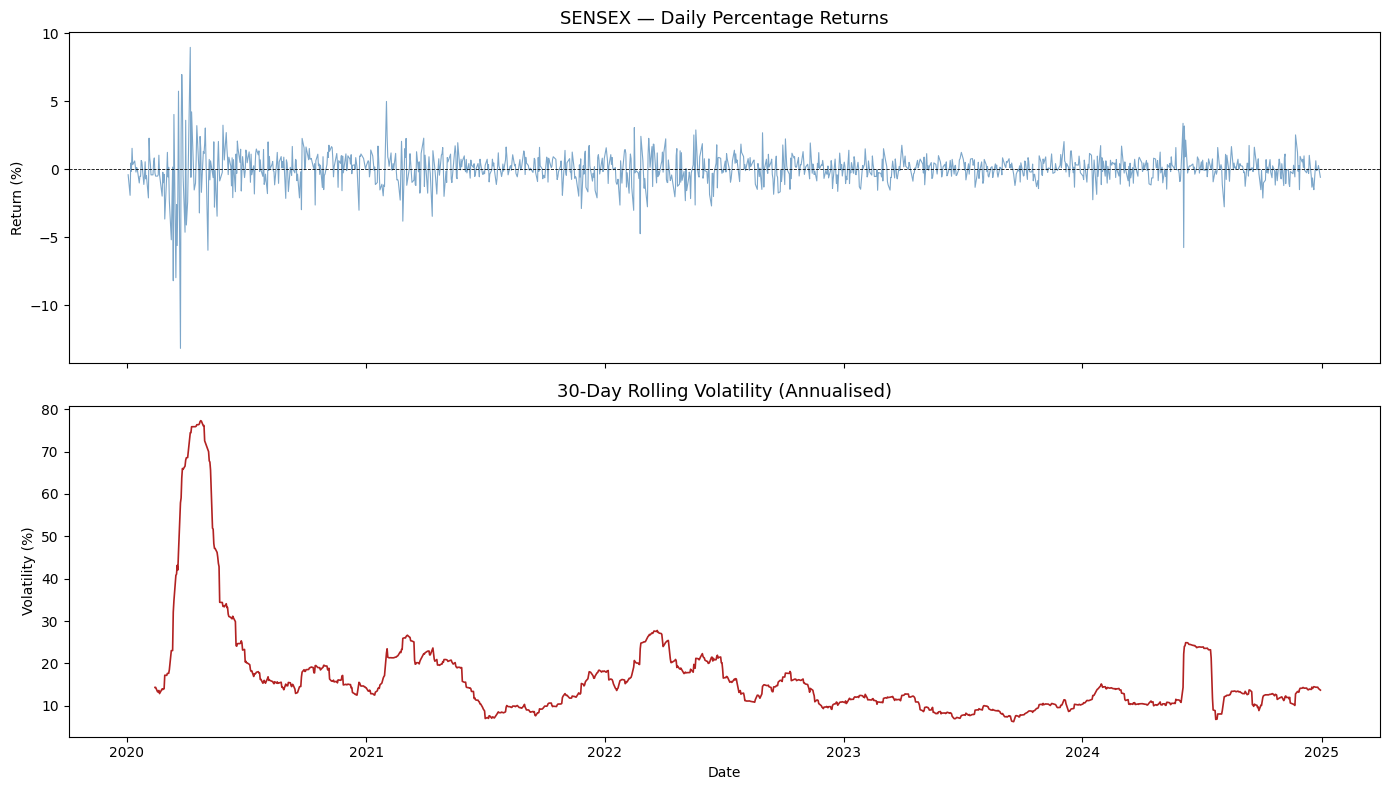

Notice the volatility spikes around March 2020 (COVID crash)


In [11]:
sensex['rolling_vol_30d'] = sensex['returns'].rolling(30).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(sensex.index, sensex['returns'], color='steelblue', linewidth=0.8, alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[0].set_title('SENSEX — Daily Percentage Returns', fontsize=13)
axes[0].set_ylabel('Return (%)')

axes[1].plot(sensex.index, sensex['rolling_vol_30d'], color='firebrick', linewidth=1.2)
axes[1].set_title('30-Day Rolling Volatility (Annualised)', fontsize=13)
axes[1].set_ylabel('Volatility (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print('Notice the volatility spikes around March 2020 (COVID crash)')

## 11. Compare Multiple BSE Stocks

In [12]:
compare_tickers = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS']
close_prices = {}

for t in compare_tickers:
    data = get_stock_data(t, '2020-01-01', '2024-12-31')
    close_prices[t] = data['Close']

price_df = pd.DataFrame(close_prices)

# Normalising to 100 at start for comparison
norm = price_df / price_df.iloc[0] * 100

fig = px.line(
    norm,
    title='Normalised Price Performance — Top NSE Stocks (Base=100, Jan 2020)',
    template='plotly_white',
    height=450,
    labels={'value': 'Normalised Price', 'index': 'Date', 'variable': 'Ticker'}
)
fig.show()

## 12. Return Distribution

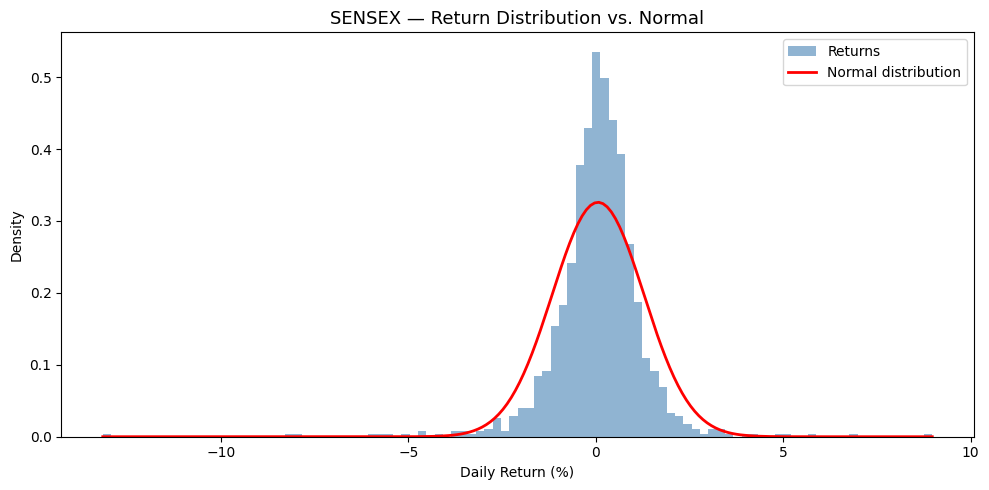

Skewness : -1.3111   (negative = left-skewed)
Kurtosis : 19.0407  (> 0 = fat tails — expected for stocks)


In [13]:
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sensex['returns'], bins=100, density=True, color='steelblue', alpha=0.6, label='Returns')

# Overlay normal distribution for comparison
mu, sigma = sensex['returns'].mean(), sensex['returns'].std()
x = np.linspace(sensex['returns'].min(), sensex['returns'].max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal distribution')

ax.set_title('SENSEX — Return Distribution vs. Normal', fontsize=13)
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Skewness : {sensex["returns"].skew():.4f}   (negative = left-skewed)')
print(f'Kurtosis : {sensex["returns"].kurtosis():.4f}  (> 0 = fat tails — expected for stocks)')